# 202302904 선태욱 Problem3

In [6]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## InventoryEnv

In [7]:
class InventoryEnv:
    def __init__(self, T=100, I_max=50, Q_max=25, K=100, C=3, H=5, P=20, L=15):
        self.T = T
        self.I_max = I_max
        self.Q_max = Q_max
        self.K = K
        self.C = C
        self.H = H
        self.P = P
        self.L = L

        self.state_dim = 2
        self.terminal_states = [(self.T, I) for I in range(self.I_max + 1)]
        self.action_dim = self.Q_max + 1

    def reset(self):
        self.state = (0, 0)
        return np.array(self.state, dtype=np.float32)

    def step(self, action):
        t, I = self.state
        q = min(action, self.I_max - I)
        I_opening = I + q
        D = np.random.poisson(self.L)
        lost_sales = max(D - I_opening, 0)
        I_closing = max(I_opening - D, 0)

        order_cost = (self.K + self.C * q) if q > 0 else 0
        holding_cost = self.H * I_closing
        penalty_cost = self.P * lost_sales
        reward = -(order_cost + holding_cost + penalty_cost)

        self.state = (t + 1, I_closing)
        done = self.state in self.terminal_states

        return np.array(self.state, dtype=np.float32), reward, done

## (a) Policy Network

- Hidden layers: 1
- Hidden nodes: 128
- Activation: ReLU
- Output: logits → Categorical distribution
- Optimizer: Adam
- Learning rate: 0.001

In [8]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        return self.net(state)  # logits 반환

## (b) REINFORCE with Greedy Rollout Baseline

In [9]:
class REINFORCE_Learning:
    """
    0. Initialization
    """
    def __init__(self, state_dim, action_dim, gamma=0.99, alpha=0.001,
                 rollout_num=1, baseline_weight=0.2, use_greedy_baseline=True):
        self.state_dim = state_dim
        self.action_dim = action_dim

        self.policy = PolicyNetwork(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=alpha)

        self.gamma = gamma
        self.rollout_num = rollout_num
        self.baseline_weight = baseline_weight
        self.use_greedy_baseline = use_greedy_baseline

    """
    1. Stochastic action selection (policy network)
    """
    def choose_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        logits = self.policy(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.squeeze()

    """
    2. Greedy action selection (for baseline rollout)
    """
    def choose_greedy_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.policy(state_t)
            action = torch.argmax(logits, dim=1)
        return action.item()

    """
    3. Compute return G_t for each time step
       G_t = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...
    """
    def compute_returns(self, rewards):
        returns = []
        for t in range(len(rewards)):
            G = sum(self.gamma ** (k - t) * rewards[k] for k in range(t, len(rewards)))
            returns.append(G)
        return torch.tensor(returns, dtype=torch.float32).to(device)

    """
    4. Greedy rollout baseline
       - 현재 정책으로 greedy하게 끝까지 플레이하여 baseline return 계산
       - env를 deepcopy하여 현재 상태에서 독립적으로 rollout
    """
    def greedy_rollout_baseline(self, env, state):
        baseline = 0
        for _ in range(self.rollout_num):
            rollout_env = copy.deepcopy(env)  # 현재 env 상태 복사
            rollout_state = state
            rewards = []
            done = False

            while not done:
                action = self.choose_greedy_action(rollout_state)
                # InventoryEnv: (next_state, reward, done) — info 없음
                next_state, reward, done = rollout_env.step(action)
                rewards.append(reward)
                rollout_state = next_state

            baseline += self.compute_returns(rewards)[0].item()

        return baseline / self.rollout_num

    """
    5. REINFORCE update
       loss = -sum_t [ log pi(a_t|s_t) * (G_t - baseline_t) ]
    """
    def learn(self, log_probs, rewards, baselines=None):
        returns = self.compute_returns(rewards)

        if self.use_greedy_baseline and baselines is not None:
            baselines_t = torch.tensor(baselines, dtype=torch.float32).to(device)
            advantages = returns - self.baseline_weight * baselines_t
        else:
            advantages = returns

        # Advantage 정규화 (분산 감소)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        loss = sum(-log_prob * adv.detach() for log_prob, adv in zip(log_probs, advantages))

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

## (c) 훈련 (1,000 에피소드, with greedy rollout baseline)

In [10]:
env = InventoryEnv()

num_episodes = 1000

agent = REINFORCE_Learning(
    state_dim=env.state_dim,
    action_dim=env.action_dim,
    use_greedy_baseline=True   # Bonus: baseline 활용
)

returns_list = []

for episode in range(num_episodes):
    state = env.reset()   # InventoryEnv: state만 반환
    episode_return = 0
    log_probs = []
    rewards = []
    baselines = []
    done = False

    while not done:
        # Greedy rollout baseline: 현재 상태에서 greedy 정책으로 끝까지 실행
        if agent.use_greedy_baseline:
            baseline = agent.greedy_rollout_baseline(env, state)
            baselines.append(baseline)

        action, log_prob = agent.choose_action(state)
        # InventoryEnv: (next_state, reward, done) — info 없음
        next_state, reward, done = env.step(action)

        log_probs.append(log_prob)
        rewards.append(reward)
        episode_return += reward
        state = next_state

    # 에피소드 종료 후 policy update
    if agent.use_greedy_baseline:
        loss = agent.learn(log_probs, rewards, baselines)
    else:
        loss = agent.learn(log_probs, rewards)

    returns_list.append(episode_return)

    if (episode + 1) % 100 == 0:
        avg = np.mean(returns_list[-100:])
        print(f"[Episode {episode+1}] Avg Return (last 100): {avg:.1f}")

[Episode 100] Avg Return (last 100): -20522.9
[Episode 200] Avg Return (last 100): -20307.1
[Episode 300] Avg Return (last 100): -20511.2
[Episode 400] Avg Return (last 100): -20313.5
[Episode 500] Avg Return (last 100): -20172.6
[Episode 600] Avg Return (last 100): -20055.2
[Episode 700] Avg Return (last 100): -20062.9
[Episode 800] Avg Return (last 100): -22399.0
[Episode 900] Avg Return (last 100): -20150.7
[Episode 1000] Avg Return (last 100): -20202.4


## 학습 곡선

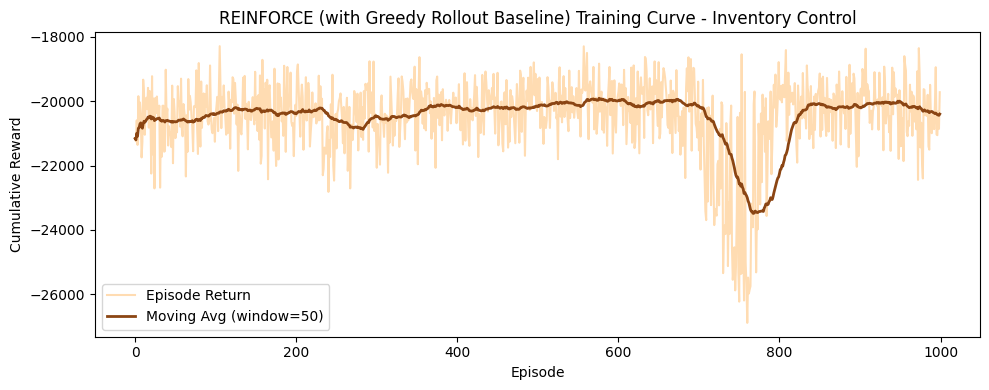

In [14]:
window = 50
moving_avg = [np.mean(returns_list[max(0, i-window):i+1]) for i in range(len(returns_list))]

plt.figure(figsize=(10, 4))
plt.plot(returns_list, alpha=0.3, color='darkorange', label='Episode Return')
plt.plot(moving_avg, color='saddlebrown', linewidth=2, label=f'Moving Avg (window={window})')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('REINFORCE (with Greedy Rollout Baseline) Training Curve - Inventory Control')
plt.legend()
plt.tight_layout()
plt.savefig('reinforce_learning_curve.png', dpi=150)
plt.show()

## 테스트 (100 에피소드) + 발주 행동 분석

In [15]:
agent.policy.eval()

test_episodes = 100
test_returns = []
order_by_inventory = {I: [] for I in range(env.I_max + 1)}

for episode in range(test_episodes):
    state = env.reset()
    episode_return = 0
    done = False

    while not done:
        _, I = int(state[0]), int(state[1])
        action = agent.choose_greedy_action(state)  # 테스트는 greedy
        order_by_inventory[I].append(action)

        next_state, reward, done = env.step(action)
        episode_return += reward
        state = next_state

    test_returns.append(episode_return)

print(f"\n[Test] Average Return over {test_episodes} episodes: {np.mean(test_returns):.1f}")
print(f"[Test] Std: {np.std(test_returns):.1f}")


[Test] Average Return over 100 episodes: -20167.4
[Test] Std: 695.3


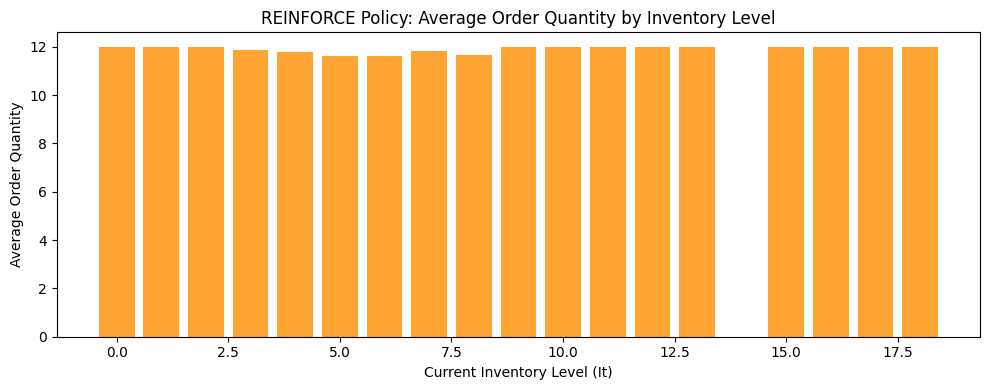


[Policy Analysis] Inventory Level -> Avg Order Quantity
  I= 0 -> avg order = 12.00
  I= 1 -> avg order = 12.00
  I= 2 -> avg order = 12.00
  I= 3 -> avg order = 11.87
  I= 4 -> avg order = 11.78
  I= 5 -> avg order = 11.61
  I= 6 -> avg order = 11.63
  I= 7 -> avg order = 11.84
  I= 8 -> avg order = 11.67
  I= 9 -> avg order = 12.00
  I=10 -> avg order = 12.00
  I=11 -> avg order = 12.00
  I=12 -> avg order = 12.00
  I=13 -> avg order = 12.00
  I=15 -> avg order = 12.00
  I=16 -> avg order = 12.00
  I=17 -> avg order = 12.00
  I=18 -> avg order = 12.00


In [16]:
inventory_levels = [I for I in range(env.I_max + 1) if order_by_inventory[I]]
avg_orders = [np.mean(order_by_inventory[I]) for I in inventory_levels]

plt.figure(figsize=(10, 4))
plt.bar(inventory_levels, avg_orders, color='darkorange', alpha=0.8)
plt.xlabel('Current Inventory Level (It)')
plt.ylabel('Average Order Quantity')
plt.title('REINFORCE Policy: Average Order Quantity by Inventory Level')
plt.tight_layout()
plt.savefig('reinforce_policy_analysis.png', dpi=150)
plt.show()

print("\n[Policy Analysis] Inventory Level -> Avg Order Quantity")
for I, q in zip(inventory_levels, avg_orders):
    print(f"  I={I:2d} -> avg order = {q:.2f}")